Libraries

In [3]:
!pip install statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

sns.set_style("whitegrid")

Drive Access

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Load Data

In [5]:
responses = pd.read_excel("/content/drive/MyDrive/EDA/Responses(EDA).xlsx", sheet_name="Responses")

responses.head(83)

,SEX,PROGRAM,GWA,LI1,LI2,LI3,LI4,LI5,LI6,CG1,...,TS5,DP1,DP2,DP3,DP4,EC1,EC2,EC3,EC4,EC5
0,Female,Bachelor of Science in Statistics,2.00,4,4,4,4,4,4,3,...,3,4,3,3,4,4,3,3,4,3
1,Female,Bachelor of Science in Statistics,1.21,3,3,3,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
2,Male,Bachelor of Science in Statistics,1.23,4,3,4,4,3,4,4,...,3,4,4,4,3,4,4,4,4,4
3,Male,Bachelor of Science in Statistics,1.50,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
4,Female,Bachelor of Science in Statistics,1.58,4,4,2,3,4,4,3,...,2,3,3,2,3,4,4,4,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,Male,Bachelor of Science in Astronomy,2.21,4,4,3,3,3,4,3,...,3,3,4,3,3,4,4,4,4,4
78,Female,Bachelor of Science in Astronomy,2.50,4,3,3,3,4,4,4,...,3,3,3,3,3,4,4,4,4,4
79,Female,Bachelor of Science in Astronomy,2.32,3,4,3,3,4,4,3,...,2,3,3,3,3,4,4,4,4,4
80,Female,Bachelor of Science in Astronomy,2.43,3,4,3,3,3,4,4,...,3,3,3,3,3,4,4,4,4,4


Composite Scores of Variables (Domains Scores)

In [6]:
responses["Personal_Inputs"] = responses[["LI1","LI2","LI3","LI4","LI5","LI6","CG1","CG2","CG3","CG4"]].mean(axis=1)
responses["Contextual_Factors"] = responses[["AE1","AE2","AE3","AE4","AE5","AE6","IS1","IS2","IS3","IS4","CR1","CR2","CR3","CR4"]].mean(axis=1)
responses["Self_Efficacy"] = responses[["SE1","SE2","SE3","SE4","SE5"]].mean(axis=1)
responses["Outcome_Expectations"] = responses[["OE1","OE2","OE3","OE4","OE5"]].mean(axis=1)
responses["Career_Readiness"] = responses[["TS1","TS2","TS3","TS4","DP1","DP2","DP3","DP4","EC1","EC2","EC3","EC4","EC5"]].mean(axis=1)

responses[["Personal_Inputs","Contextual_Factors","Self_Efficacy","Outcome_Expectations","Career_Readiness"]].head(83)

,Personal_Inputs,Contextual_Factors,Self_Efficacy,Outcome_Expectations,Career_Readiness
0,3.7,3.285714,3.2,3.2,3.538462
1,3.7,3.857143,3.0,4.0,4.000000
2,3.8,3.285714,3.8,3.6,3.846154
3,3.0,3.000000,3.0,3.0,3.000000
4,3.0,3.000000,2.6,4.0,3.076923
...,...,...,...,...,...
77,3.5,3.071429,3.0,4.0,3.461538
78,3.5,2.642857,2.8,4.0,3.384615
79,3.3,2.714286,3.0,3.0,3.153846
80,3.5,2.857143,3.0,3.6,3.384615


Fit Model

In [7]:
X = responses[["Personal_Inputs","Contextual_Factors","Self_Efficacy","Outcome_Expectations"]]
y = responses["Career_Readiness"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Career_Readiness   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.618
Method:                 Least Squares   F-statistic:                     33.72
Date:                Thu, 21 May 2026   Prob (F-statistic):           3.04e-16
Time:                        07:35:45   Log-Likelihood:                 14.091
No. Observations:                  82   AIC:                            -18.18
Df Residuals:                      77   BIC:                            -6.149
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.8295 

Normality Test

In [8]:
#Shapiro
for var in ["Personal_Inputs","Contextual_Factors","Self_Efficacy","Outcome_Expectations","Career_Readiness"]:stat, p = stats.shapiro(responses[var].dropna())
print(f"{var}: Shapiro-Wilk p={p:.4f}")

#Skewness & Kurtosis
for var in ["Personal_Inputs","Contextual_Factors","Self_Efficacy","Outcome_Expectations","Career_Readiness"]:
  skew = stats.skew(responses[var].dropna())
  kurt = stats.kurtosis(responses[var].dropna())
  print(f"{var}: Skewness={skew:.3f}, Kurtosis={kurt:.3f}")


Career_Readiness: Shapiro-Wilk p=0.0078
Personal_Inputs: Skewness=-0.138, Kurtosis=-0.745
Contextual_Factors: Skewness=-0.216, Kurtosis=1.433
Self_Efficacy: Skewness=0.334, Kurtosis=0.143
Outcome_Expectations: Skewness=-0.021, Kurtosis=-1.330
Career_Readiness: Skewness=0.193, Kurtosis=-0.928


In [9]:
#In Table
variables = ["Personal_Inputs","Contextual_Factors","Self_Efficacy","Outcome_Expectations","Career_Readiness"]
results = []

for var in variables:
  data = responses[var].dropna()
  shapiro_stat, shapiro_p = stats.shapiro(data)
  skew = stats.skew(data)
  kurt = stats.kurtosis(data)
  results.append({"Variable": var, "Shapiro-Wilk p": round(shapiro_p, 4), "Skewness": round(skew, 3), "Kurtosis": round(kurt, 3)})

normality_table = pd.DataFrame(results)
print(normality_table)

               Variable  Shapiro-Wilk p  Skewness  Kurtosis
0       Personal_Inputs          0.0367    -0.138    -0.745
1    Contextual_Factors          0.0027    -0.216     1.433
2         Self_Efficacy          0.0000     0.334     0.143
3  Outcome_Expectations          0.0000    -0.021    -1.330
4      Career_Readiness          0.0078     0.193    -0.928


Homoscedasticity (Breusch-Pagan)

In [10]:
bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ["Lagrange Multiplier Statistic", "p-value", "F Statistic","F p-value"]

bp_table = pd.DataFrame([bp_test], columns=labels)
print(bp_table)

   Lagrange Multiplier Statistic   p-value  F Statistic  F p-value
0                      13.759329  0.008104     3.881367   0.006333


Multicollinearity (VIF & Tolerance)

In [11]:
vif_data = pd.DataFrame()
vif_data["Predictor"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data["Tolerance"] = 1 / vif_data["VIF"]
vif_data

,Predictor,VIF,Tolerance
0,const,99.310846,0.010069
1,Personal_Inputs,2.085041,0.479607
2,Contextual_Factors,2.208134,0.452871
3,Self_Efficacy,2.243295,0.445773
4,Outcome_Expectations,1.739982,0.574719


Autocorrelation (Durbin-Watson)

In [12]:
from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(model.resid)
print("Durbin-Watson", dw_stat)

Durbin-Watson 1.7451056322540142


PLOTS

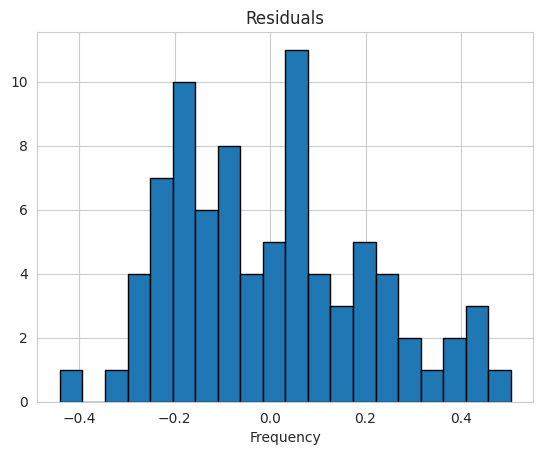

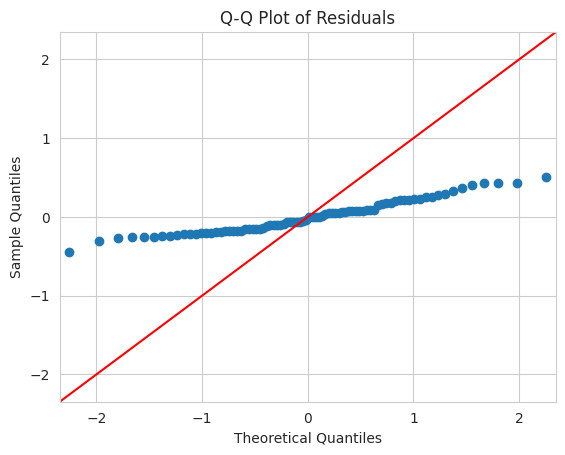

In [14]:
#Histogram of Residuals
plt.hist(model.resid, bins=20, edgecolor='black')
plt.xlabel("Frequency")
plt.title("Residuals")
plt.show()

#Q-Q Plot (Normality)
sm.qqplot(model.resid, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

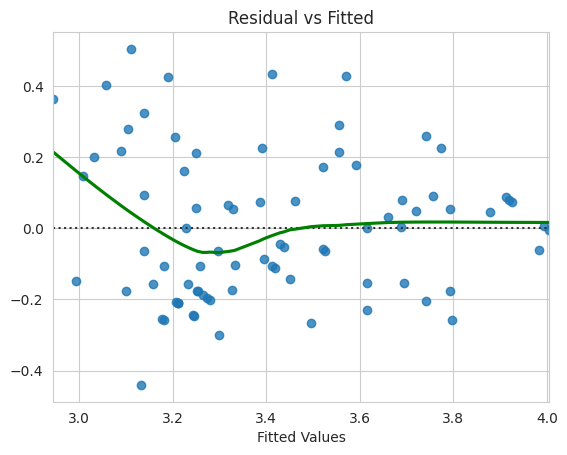

In [15]:
#Residuals/Fitted (Linearity)
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, line_kws={'color': 'green'})
plt.xlabel("Fitted Values")
plt.title("Residual vs Fitted")
plt.show()

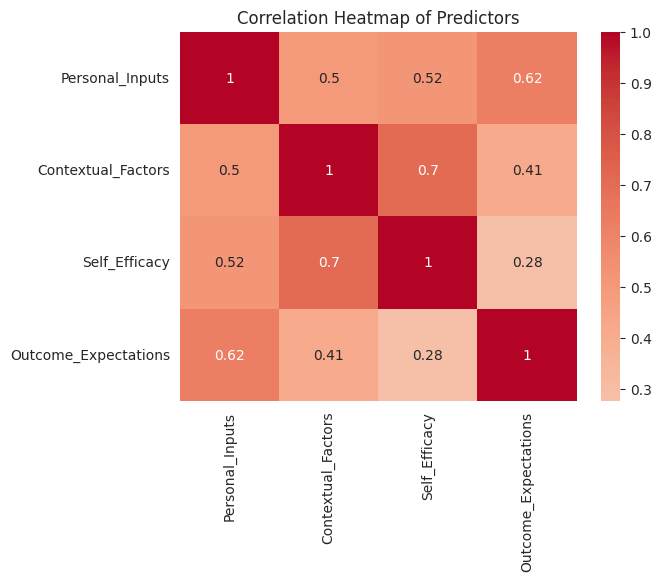

In [16]:
#Correlation Heatmap
corr = responses[["Personal_Inputs","Contextual_Factors","Self_Efficacy","Outcome_Expectations"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Predictors")
plt.show()

Reliability Test (Cronbach Alpha)

In [17]:
!pip install pingouin
import pingouin as pg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 4.9 MB/s eta 0:00:00


In [21]:
#PERSONAL INPUTS
li_alpha, _ = pg.cronbach_alpha(data=responses[['LI1','LI2','LI3','LI4','LI5','LI6']])
print("Cronbach's alpha (Learning_Interest):", round(li_alpha, 3))

cg_alpha, _ = pg.cronbach_alpha(data=responses[['CG1','CG2','CG3','CG4']])
print("Cronbach's alpha (Career_Goals):", round(cg_alpha, 3))

#CONTEXTUAL FACTORS
ae_alpha, _ = pg.cronbach_alpha(data=responses[['AE1','AE2','AE3','AE4','AE5','AE6']])
print("Cronbach's alpha (AI_Tools_Exposure):", round(ae_alpha, 3))

is_alpha, _ = pg.cronbach_alpha(data=responses[['IS1','IS2','IS3','IS4']])
print("Cronbach's alpha (Internship_Quality):", round(is_alpha, 3))

cr_alpha, _ = pg.cronbach_alpha(data=responses[['CR1','CR2','CR3','CR4']])
print("Cronbach's alpha (Curriculum_Responsiveness):", round(cr_alpha, 3))

#SELF-EFFICACY
se_alpha, _ = pg.cronbach_alpha(data=responses[['SE1','SE2','SE3','SE4','SE5']])
print("Cronbach's alpha (Self_Efficacy):", round(se_alpha, 3))

#OUTCOME EXPECTATIONS
oe_alpha, _ = pg.cronbach_alpha(data=responses[['OE1','OE2','OE3','OE4']])
print("Cronbach's alpha (Outcome_Expectations):", round(oe_alpha, 3))

#CAREER READINESS
ts_alpha, _ = pg.cronbach_alpha(data=responses[['TS1','TS2','TS3','TS4']])
print("Cronbach's alpha (Technical_Skills):", round(ts_alpha, 3))

dp_alpha, _ = pg.cronbach_alpha(data=responses[['DP1','DP2','DP3','DP4']])
print("Cronbach's alpha (Digital_Preparedness):", round(dp_alpha, 3))

ec_alpha, _ = pg.cronbach_alpha(data=responses[['EC1','EC2','EC3','EC4','EC5']])
print("Cronbach's alpha (Ethical_Confidence):", round(ec_alpha, 3))

alpha_table = pd.DataFrame({
    'Domain': [
        'Learning_Interest','Career_Goals','AI_Tools_Exposure','Internship_Quality','Curriculum_Responsiveness','Self_Efficacy','Outcome_Expectations',
        'Technical_Skills','Digital_Preparedness','Ethical_Confidence'],
    'Cronbach_Alpha': [
        round(li_alpha,3), round(cg_alpha,3), round(ae_alpha,3),
        round(is_alpha,3), round(cr_alpha,3),
        round(se_alpha,3), round(oe_alpha), round(ts_alpha,3), round(dp_alpha,3), round(ec_alpha,3)
    ]})

print(alpha_table)


Cronbach's alpha (Learning_Interest): 0.811
Cronbach's alpha (Career_Goals): 0.822
Cronbach's alpha (AI_Tools_Exposure): 0.787
Cronbach's alpha (Internship_Quality): 0.883
Cronbach's alpha (Curriculum_Responsiveness): 0.892
Cronbach's alpha (Self_Efficacy): 0.861
Cronbach's alpha (Outcome_Expectations): 0.646
Cronbach's alpha (Technical_Skills): 0.793
Cronbach's alpha (Digital_Preparedness): 0.812
Cronbach's alpha (Ethical_Confidence): 0.866
                      Domain  Cronbach_Alpha
0          Learning_Interest           0.811
1               Career_Goals           0.822
2          AI_Tools_Exposure           0.787
3         Internship_Quality           0.883
4  Curriculum_Responsiveness           0.892
5              Self_Efficacy           0.861
6       Outcome_Expectations           1.000
7           Technical_Skills           0.793
8       Digital_Preparedness           0.812
9         Ethical_Confidence           0.866


#Interpretation

We used the composite scores for each variables as the reliability test yielded as highly reliable with croncbach's alpha > .70, meaning that our instrument measures the variables being observed.

Since our data did not follow a normal distribution and yieled as heteroscedastic with p-values < .05, meaning that our data violates the standard assumptions.

Despite these, the VIF results fall under 5, meaning that our predictors are independent from one another and we can safely test for their unique influence on Career Readiness.



heatmap of predictos on DV

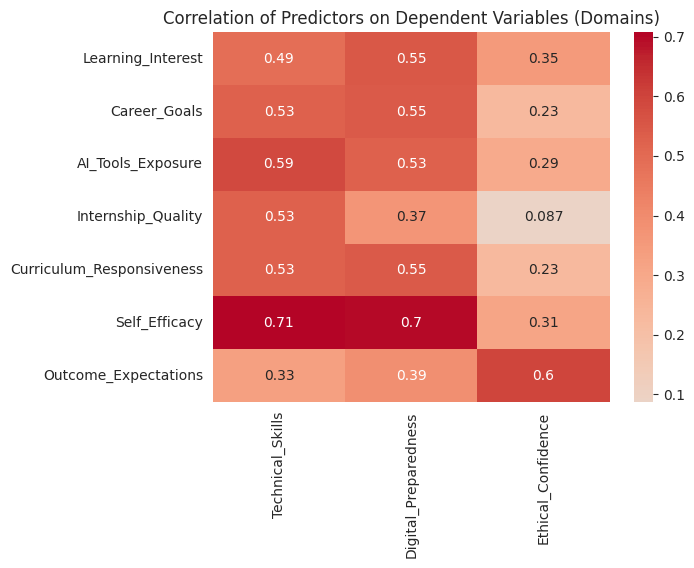

In [22]:
#PREDICTORS ON DVs
responses["Learning_Interest"] = responses[['LI1','LI2','LI3','LI4','LI5','LI6']].mean(axis=1)
responses["Career_Goals"] = responses[['CR1','CR2','CR3','CR4']].mean(axis=1)
responses["AI_Tools_Exposure"] = responses[['AE1','AE2','AE3','AE4','AE5','AE6']].mean(axis=1)
responses["Internship_Quality"] = responses[['IS1','IS2','IS3','IS4']].mean(axis=1)
responses["Curriculum_Responsiveness"] = responses[['CR1','CR2','CR3','CR4']].mean(axis=1)
responses["Self_Efficacy"] = responses[['SE1','SE2','SE3','SE4','SE5']].mean(axis=1)
responses["Outcome_Expectations"] = responses[['OE1','OE2','OE3','OE4']].mean(axis=1)
responses["Technical_Skills"] = responses[['TS1','TS2','TS3','TS4']].mean(axis=1)
responses["Digital_Preparedness"] = responses[['DP1','DP2','DP3','DP4']].mean(axis=1)
responses["Ethical_Confidence"] = responses[['EC1','EC2','EC3','EC4','EC5']].mean(axis=1)

pred = ["Learning_Interest", "Career_Goals", "AI_Tools_Exposure", "Internship_Quality","Curriculum_Responsiveness","Self_Efficacy","Outcome_Expectations"]
dvs = ["Technical_Skills","Digital_Preparedness","Ethical_Confidence"]

domain_correlation = responses[pred + dvs].corr().loc[pred, dvs]
sns.heatmap(domain_correlation, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Predictors on Dependent Variables (Domains)")
plt.show()